Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

Set your dataset path

In [3]:
dataset_path = "/content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(dataset_path, "Train")
test_dir = os.path.join(dataset_path, "Test")

img_height, img_width = 28, 28
num_classes = 10

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train
Test path: /content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test


Load images using PIL

In [4]:
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_names = [c for c in class_names if os.path.isdir(os.path.join(folder, c))]
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Classes found in", folder, ":", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img, dtype="float32") / 255.0

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping {img_path} because of error: {e}")

    return np.array(images), np.array(labels)

Load train and test data

In [5]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("Before reshape:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

Classes found in /content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train : {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Classes found in /content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test : {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Before reshape:
x_train shape: (17000, 28, 28)
y_train shape: (17000,)
x_test shape: (3000, 28, 28)
y_test shape: (3000,)


Reshape and one-hot encode labels

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("After reshape:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

After reshape:
x_train shape: (17000, 28, 28, 1)
y_train shape: (17000, 10)
x_test shape: (3000, 28, 28, 1)
y_test shape: (3000, 10)


Show sample images

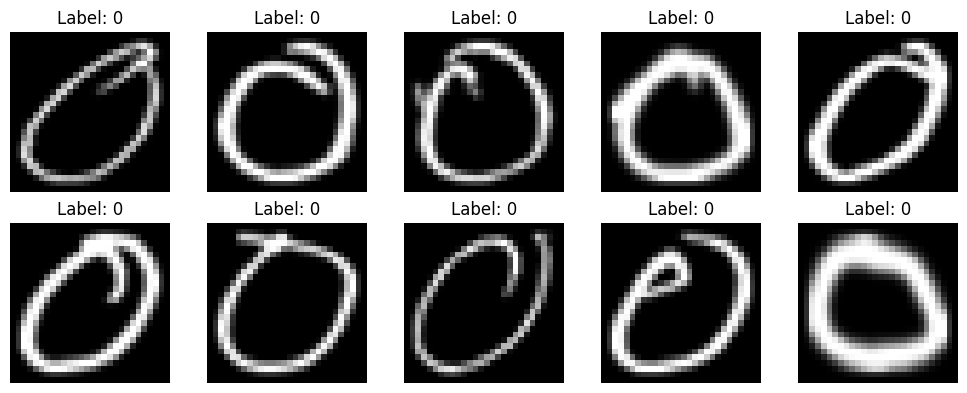

In [7]:
plt.figure(figsize=(10, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Build FCN model

In [8]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile model

In [9]:
# Using categorical_crossentropy because labels are one-hot encoded
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Train model

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/AI ML/Week4/Week4.keras",
        save_best_only=True,
        monitor="val_loss",
        mode="min"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5218 - loss: 1.5193 - val_accuracy: 0.0000e+00 - val_loss: 8.0139
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8440 - loss: 0.4995 - val_accuracy: 0.0000e+00 - val_loss: 9.3003
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9168 - loss: 0.2789 - val_accuracy: 0.0000e+00 - val_loss: 9.8369
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9441 - loss: 0.1959 - val_accuracy: 0.0000e+00 - val_loss: 10.3102
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9560 - loss: 0.1489 - val_accuracy: 0.0000e+00 - val_loss: 10.6521


Plot loss and accuracy

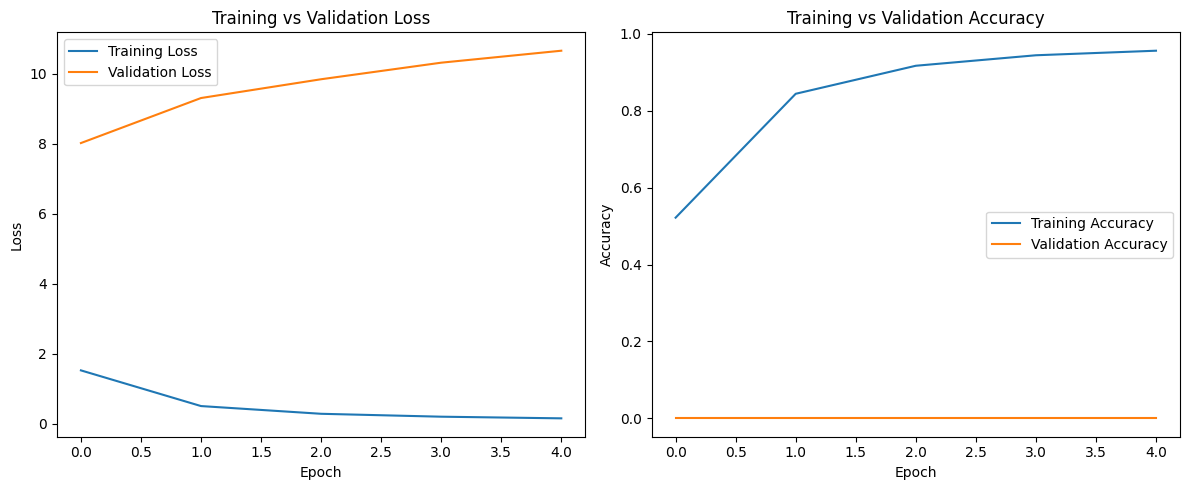

In [11]:
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Evaluate model

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

94/94 - 1s - 11ms/step - accuracy: 0.6147 - loss: 2.2041
Test Loss: 2.204092502593994
Test Accuracy: 0.6146666407585144


Save model as .h5

In [13]:
model_save_path = "/content/drive/MyDrive/AI ML/Week4/Week4.h5"
model.save(model_save_path)

print("Model saved at:", model_save_path)

Model saved at: /content/drive/MyDrive/AI ML/Week4.h5


Load model and re-evaluate

In [14]:
loaded_model = tf.keras.models.load_model(model_save_path)

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

94/94 - 1s - 12ms/step - accuracy: 0.6147 - loss: 2.2041
Loaded Model Test Loss: 2.204092502593994
Loaded Model Test Accuracy: 0.6146666407585144
